**License**

This notebook is primarily licensed under the MIT License.

Some code cells are based on or adapted from the TensorFlow Time Series Forecasting tutorial,
which is licensed under the Apache License, Version 2.0.

<details>
<summary><strong>License details</strong></summary>

**MIT License**

Copyright (c) 2023-2026 AI Course Notebook Contributors

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files to deal in the Software
without restriction, subject to the conditions of the MIT License.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND.

**Third-party code: TensorFlow Time Series Forecasting tutorial**

Portions of this notebook are based on or adapted from:

https://github.com/tensorflow/docs-l10n/blob/master/site/ja/tutorials/structured_data/time_series.ipynb

Original copyright:

```text
Copyright 2019 The TensorFlow Authors.
```

The TensorFlow-derived portions are licensed under the Apache License,
Version 2.0.

```text
Licensed under the Apache License, Version 2.0 (the "License");
you may not use those portions except in compliance with the License.
You may obtain a copy of the License at:

https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```

Modifications to the TensorFlow-derived portions were made by
AI Course Notebook Contributors.

</details>

# Time-Series Forecasting of Weather Data (a regression model using a recurrent neural network)
The goal of this hands-on session is to give you a feel for the overall workflow of building a recurrent neural network (RNN), one of the deep learning models.

In a recurrent neural network, the hidden state produced when previous data was input is also used to generate the output. It is one of the candidate models when you want to obtain some output from time-series data as input.

<br>

Conceptual diagram of a Recurrent Neural Network (RNN):
<br>

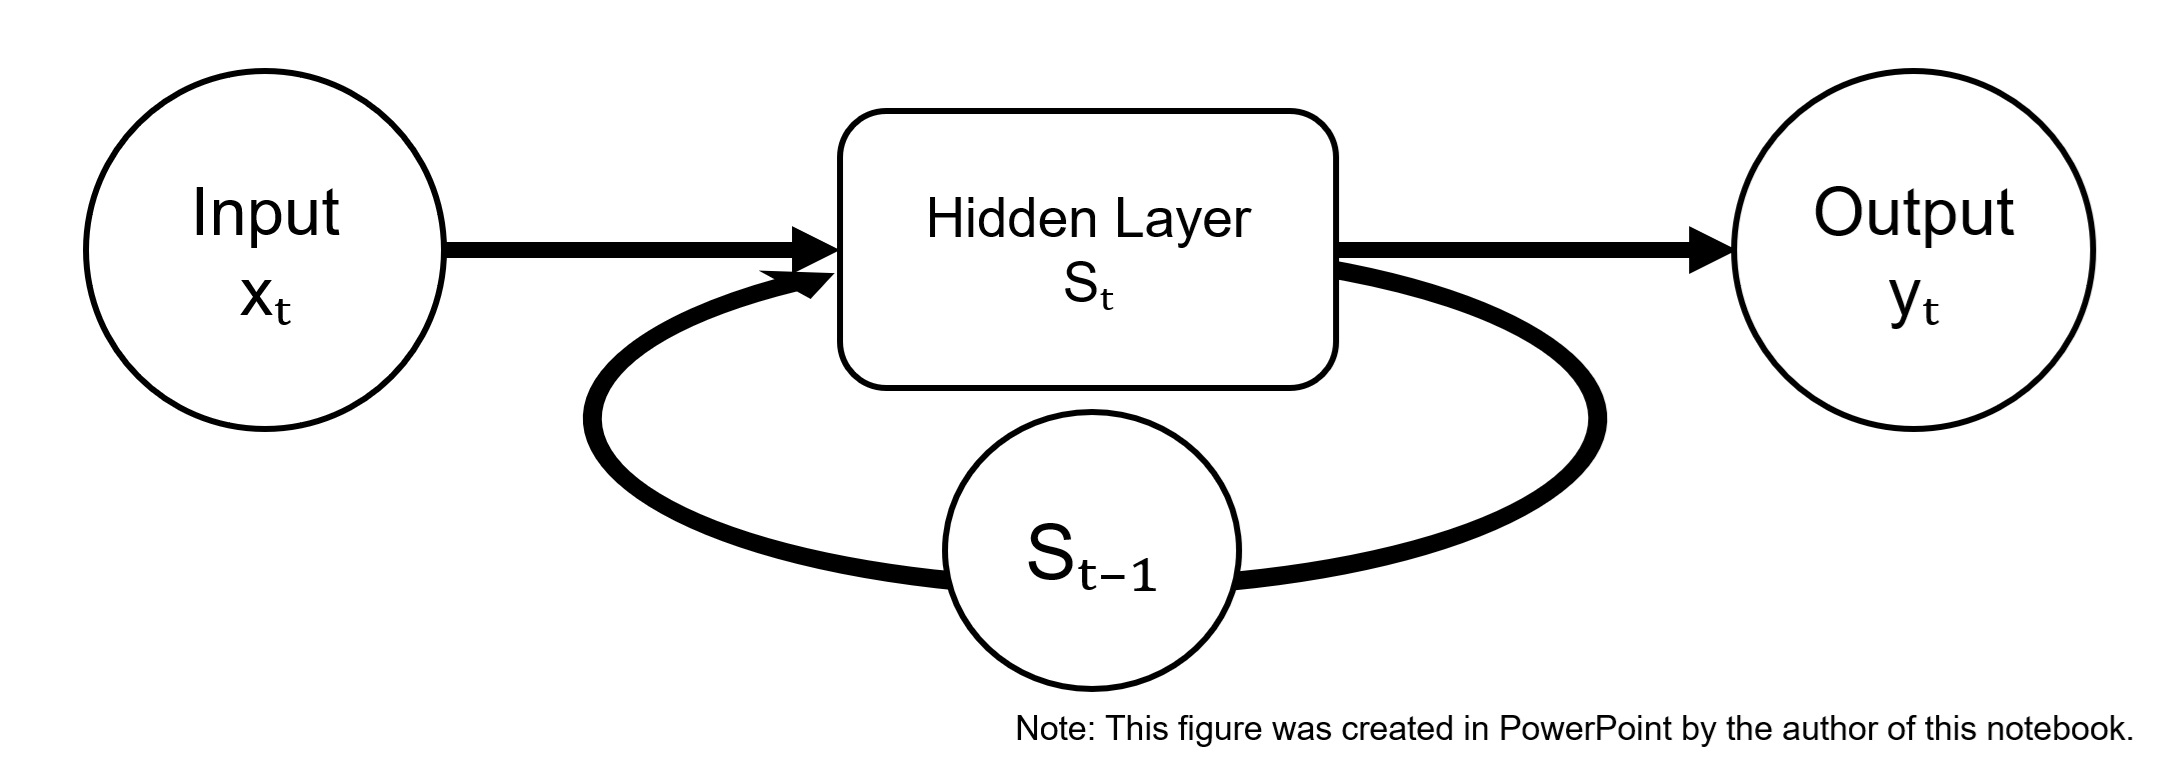

## Objective: predict future weather information from past weather information

The data we use is a [weather time-series dataset](https://www.bgc-jena.mpg.de/wetter/) recorded by the [Max Planck Institute for Biogeochemistry](https://www.bgc-jena.mpg.de/) in the German city of Jena.

Here we use a dataset prepared by author François Chollet for the book "[Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python/)".

Note that the original dataset provided by the [Max Planck Institute for Biogeochemistry](https://www.bgc-jena.mpg.de/) can be downloaded from [here](https://www.bgc-jena.mpg.de/wetter/weather_data.html).

<br>

---

This dataset contains the 15 columns shown in the table below, including temperature, atmospheric pressure, and humidity. The data has been collected at 10-minute intervals since 2003; here we use only the 7 years of weather data collected from 2009 to 2016.

<br>

　Available information (types of input data): the 15 types of weather data shown in the table below <br>
　Desired result (type of output data): **future weather data (data observed at or after the date/time of the data used to train the model)**

<br>

|Column number|Column name|Meaning|Overview|
|----|----|----|---|
|0|Date Time| Date/time | Observation date and time (10-minute intervals) |
|1|p (mbar)| Atmospheric pressure (mbar)|The force that gas molecules in the atmosphere exert on Earth's surface (the pressure caused by the weight of the atmosphere)|
|2|T (degC)| Temperature (°C)|An index representing the speed of motion and the energy state of the molecules and atoms of a substance|
|3|Tpot (K)|Potential temperature (K)|A temperature index based on a reference pressure (a temperature index that is robust to changes in pressure)|
|4|Tdew (degC) |Dew point temperature (°C)|The temperature at which the water vapor in the air reaches saturation (the temperature at which some of the water vapor turns into liquid)|
|5|rh (%) |Relative humidity (%)|The ratio of the amount of water vapor contained in the air at a given temperature to the saturation water vapor amount at that temperature|
|6|VPmax (mbar) |Saturation vapor pressure (mbar)|An index showing the pressure of the water vapor when the water vapor in the air reaches saturation at a specific temperature|
|7|VPact (mbar) |Actual vapor pressure (mbar)|An index showing the pressure of the water vapor in the air|
|8|VPdef (mbar)|Vapor pressure deficit (mbar)|The value obtained by subtracting the actual vapor pressure (VPact) from the saturation vapor pressure (VPmax)|
|9|sh (g/kg)| Specific humidity (g/kg)|The mass of water vapor in the atmosphere divided by the mass of the air|
|10|H2OC (mmol/mol) |Water vapor concentration (mole fraction)|The number of water vapor molecules divided by the total number of molecules in the air (an index showing the proportion of the air that water vapor occupies)|
|11|rho (g/m**3) |Density (g/m³)|An index showing the mass of air molecules and gaseous components in the atmosphere per unit volume|
|12|wv (m/s) |Wind velocity (m/s)|The distance the wind travels per unit time (an index representing the strength of the wind)|
|13|max. wv (m/s) |Maximum wind velocity (m/s)|An index representing the fastest wind observed within a specific time window|
|14|wd (deg) |Wind direction (deg)|An index showing the direction from which the wind blows|

<br>

Reference: [TensorFlow Core tutorial: Time series forecasting](https://www.tensorflow.org/tutorials/structured_data/time_series)


## Checking GPU availability and the TensorFlow version


In [1]:
!nvidia-smi

Thu Jun 11 02:57:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf
import sklearn

print('TensorFlow version:',tf.__version__)
print('scikit-learn version:',sklearn.__version__)

if tf.__version__ != '2.20.0':
    !pip install -q --upgrade tensorflow==2.20.0
    print('TensorFlow version:',tf.__version__)

if sklearn.__version__ != '1.6.1':
    !pip install -q --upgrade scikit-learn==1.6.1
    print('scikit-learn version:',sklearn.__version__)

TensorFlow version: 2.20.0
scikit-learn version: 1.6.1


### Importing packages


In [3]:
import os # os: standard library, handles OS-dependent operations (environment variables, creating folders, etc.)
import datetime # datetime: standard library, handles date-related data
import random # random: standard library, pseudo-random number generator
import numpy as np # numpy: one of the libraries for numerical computation
import pandas as pd # pandas: one of the libraries for tabular computation
from IPython.display import display # a function that can display some data more cleanly than print() in environments such as Colab
import matplotlib.pylab as plt # matplotlib: one of the libraries for drawing graphs
import seaborn as sns # seaborn: one of the libraries for drawing graphs
from sklearn.metrics import classification_report # one of the machine learning libraries (here used only to output Precision, Recall, and F1-Score)
# tensorboard: setup for the dashboard output of the deep learning library TensorFlow
%load_ext tensorboard
import tensorflow as tf # TensorFlow: one of the deep learning libraries

# scikit-learn: one of the libraries for machine learning
from sklearn.preprocessing import StandardScaler


### Fixing the random seed of the pseudo-random number generator

* We fix the pseudo-random number sequence generated and used in the program below.
* The random seed is the number used to initialize the generation of the pseudo-random number sequence.
* If it is not specified explicitly, it is initialized with values such as the current time.
* Here we fix the random seed to ensure reproducibility (so that the same pseudo-random number sequence is generated no matter who runs it or when).

<small> * In Colab, perfect reproducibility can be difficult due to differences in the assigned CPU/GPU and library versions.</small>


In [4]:
def set_seed(seed=123):
    # fix the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    # external Python library: make TensorFlow's neural network behave deterministically
    os.environ['TF_DETERMINISTIC_OPS'] = 'true'
    # external Python library: make TensorFlow's neural network behave deterministically
    os.environ['TF_CUDNN_DETERMINISTIC'] = 'true'
    # standard Python library: fix the seed of random
    random.seed(seed)
    # external Python library: fix the seed of Numpy
    np.random.seed(seed)
    # external Python library: fix the seed of TensorFlow
    tf.random.set_seed(seed)

set_seed(42)


## Obtaining the dataset


In [5]:
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path, _ = os.path.splitext(zip_path)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
# In this tutorial we use only hourly predictions, so
# let's subsample the 10-minute-interval data down to 1-hour intervals.

df = pd.read_csv(csv_path+"/jena_climate_2009_2016.csv")
print(f"Size of the 10-minute-interval table data: {df.shape}")
display(df.head(5))

# Slice [start:stop:step], starting from index 5 take every 6th record.
df = df[5::6]
print(f"\nSize of the 1-hour-interval table data: {df.shape}")

display_df = df.copy()
date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')
#display_df.index = date_time

# Let's take a look at the data. The first few rows look like this.
display(display_df.head(5))


Size of the 10-minute-interval table data: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3



Size of the 1-hour-interval table data: (70091, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
5,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
11,01.01.2009 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
17,01.01.2009 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
23,01.01.2009 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
29,01.01.2009 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


## Inspecting the data

We draw the table data above as a line chart with the date/time on the X-axis.


Since this is weather data, we can expect there to be yearly periodicity (seasonality).
To check the yearly periodicity, we plot all of the data.


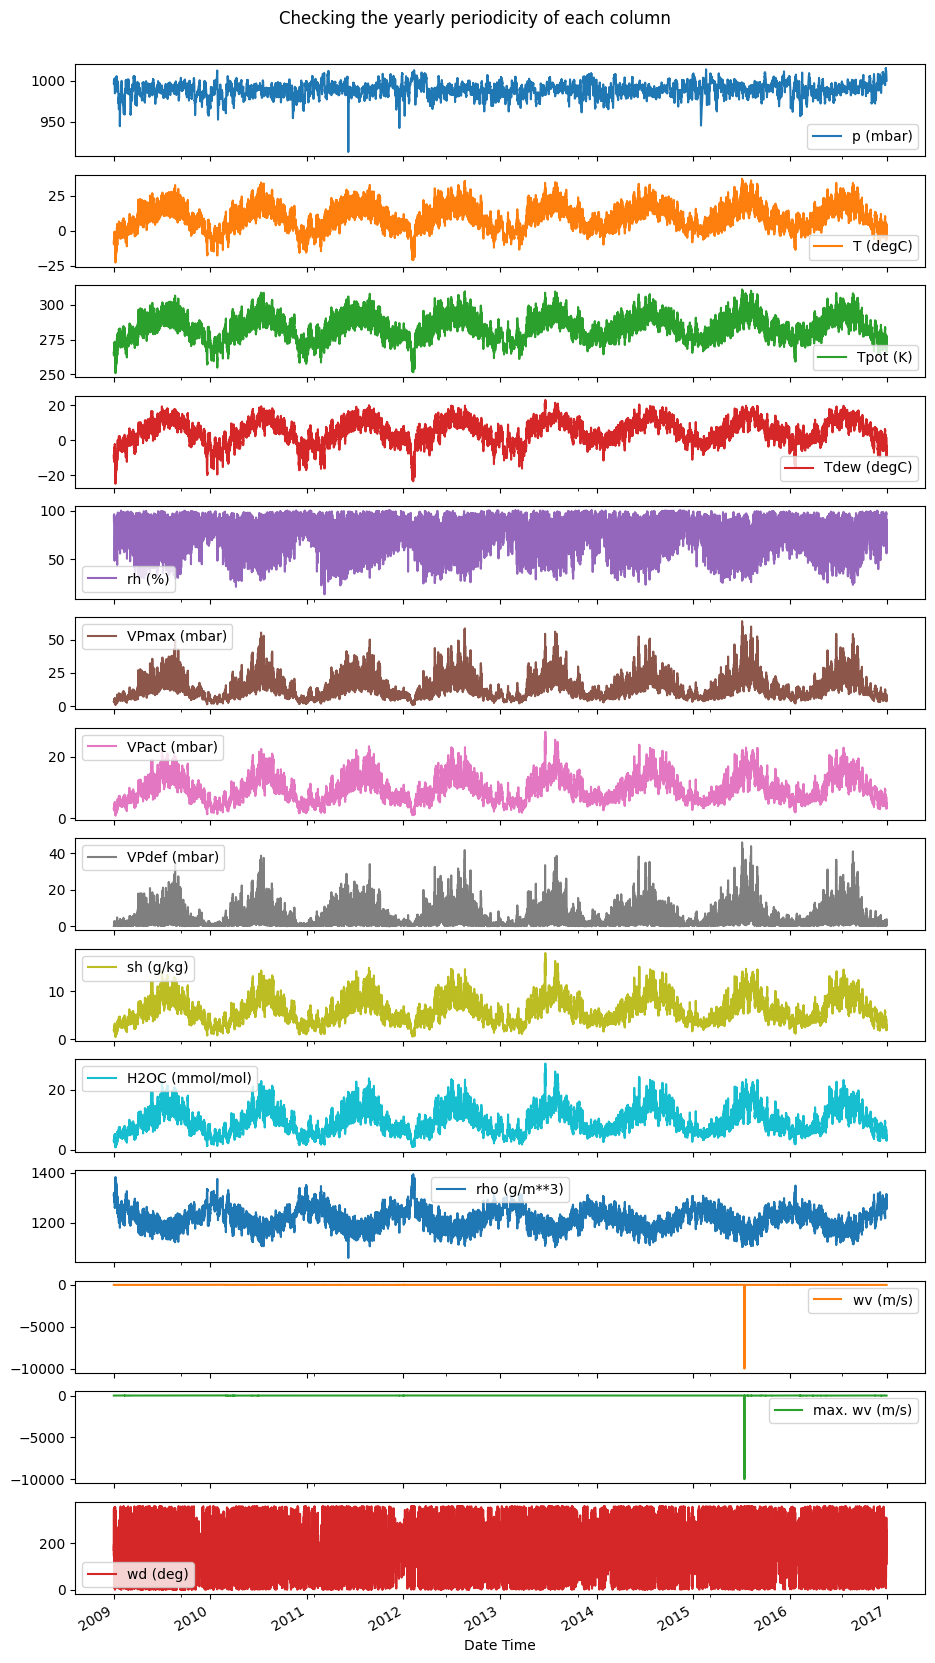

In [7]:
# Draw a line chart of all the data

plot_features = df
plot_features.index = date_time
plot_features.plot(subplots=True, title='Checking the yearly periodicity of each column', kind='line',  figsize=(10,18))
plt.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.95)
plt.show()


For some columns, clear **periodicity** can be observed.

In addition, weather data is expected to have not only yearly periodicity but also daily periodicity (usually the temperature drops at night).


To check the daily periodicity, we draw a line chart of the first two weeks of data.


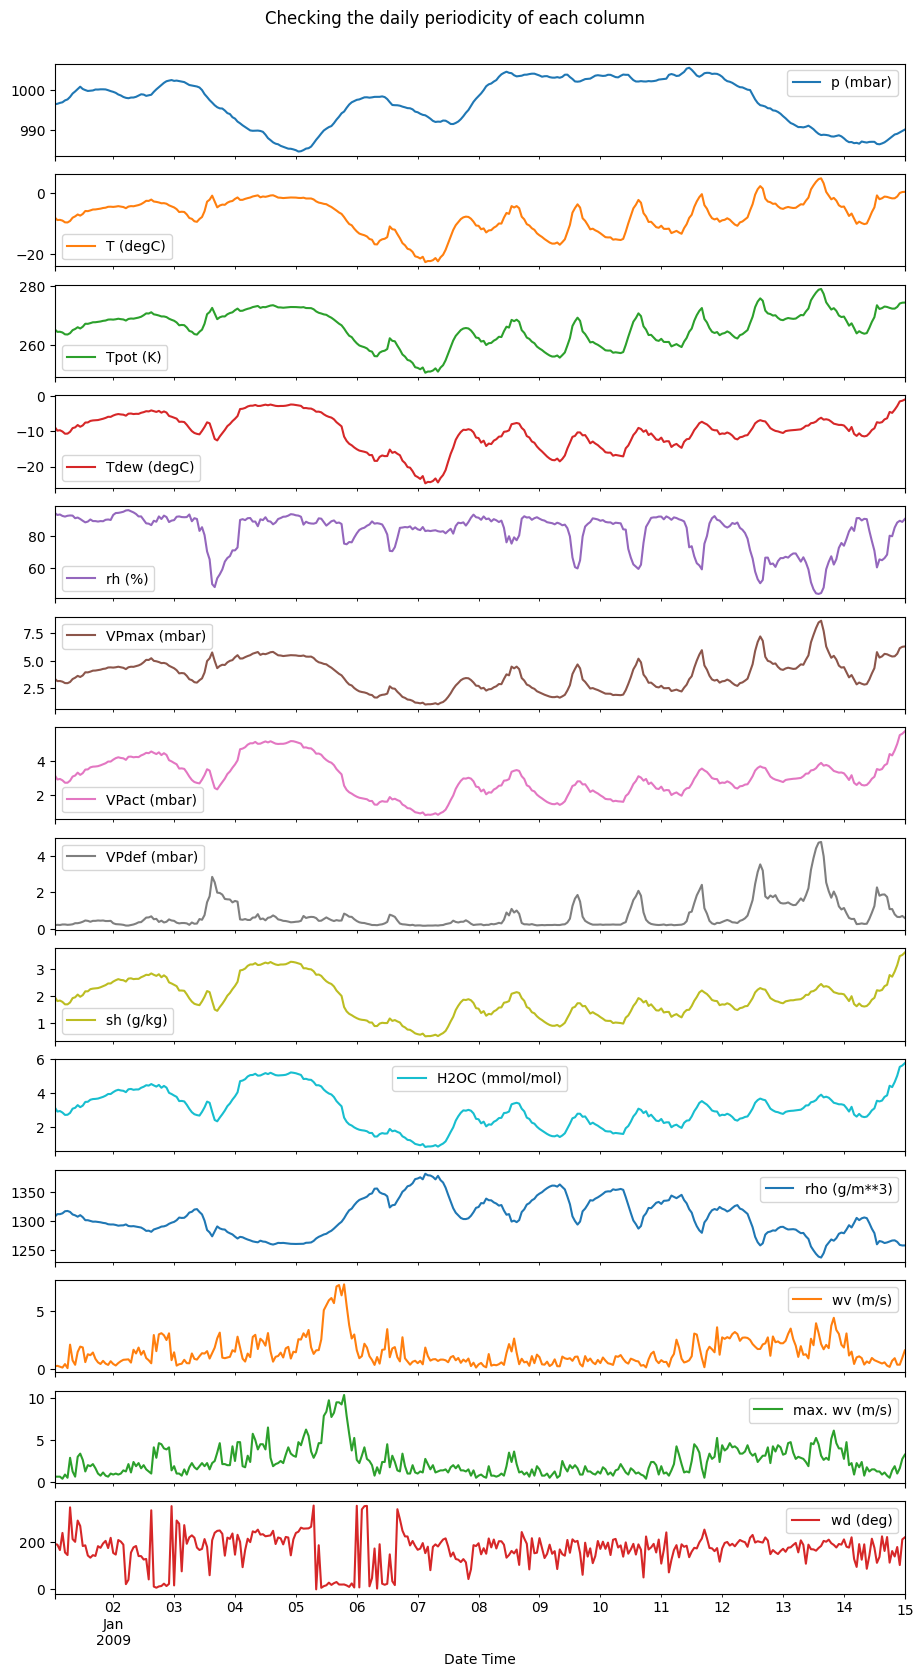

In [8]:
# Draw a line chart of the first weeks of data
# Since there is one data point per hour: 24 × 14 = 336 points are plotted.

plot_features = df[:336]
plot_features.index = date_time[:336]
_ = plot_features.plot(subplots=True, title='Checking the daily periodicity of each column', kind='line',  figsize=(10,18))
plt.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.95)
plt.show()



Also, comparing the two charts, we can see that the wind velocity column ```wv (m/s)``` and the maximum wind velocity column ```max. wv (m/s)``` contain extreme outliers.
Let's check the minimum and maximum values of each column.


In [9]:
display(df.describe().transpose())

,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.212842,8.358886,913.60,984.20,989.57,994.720,1015.29
T (degC),70091.0,9.450482,8.423384,-22.76,3.35,9.41,15.480,37.28
Tpot (K),70091.0,283.493086,8.504424,250.85,277.44,283.46,289.530,311.21
Tdew (degC),70091.0,4.956471,6.730081,-24.80,0.24,5.21,10.080,23.06
rh (%),70091.0,76.009788,16.474920,13.88,65.21,79.30,89.400,100.00
VPmax (mbar),70091.0,13.576576,7.739883,0.97,7.77,11.82,17.610,63.77
VPact (mbar),70091.0,9.533968,4.183658,0.81,6.22,8.86,12.360,28.25
VPdef (mbar),70091.0,4.042536,4.898549,0.00,0.87,2.19,5.300,46.01
sh (g/kg),70091.0,6.022560,2.655812,0.51,3.92,5.59,7.800,18.07
H2OC (mmol/mol),70091.0,9.640437,4.234862,0.81,6.29,8.96,12.490,28.74


## Handling anomalous values


The minimum value of the wind velocity column ```wv (m/s)``` and the minimum value of the maximum wind velocity column ```max. wv (m/s)``` are ```-9999```. These are very likely erroneous values that are not actual wind velocities (e.g., measurement-instrument errors).


Also, since there is a wind direction column ```wd (deg)```, if the data were measured and aggregated correctly the wind velocity should be a value greater than or equal to zero (>=0). We process the data so that any data point with a wind velocity less than 0 is set to 0.


In [10]:
# Handle the anomalous values.

wv = df['wv (m/s)']
bad_wv = wv == -9999.0
wv[bad_wv] = 0.0

max_wv = df['max. wv (m/s)']
bad_max_wv = max_wv == -9999.0
max_wv[bad_max_wv] = 0.0


display(df['wv (m/s)'].min())


print("After handling the anomalous values:")
display(df.describe().transpose())


0.0

After handling the anomalous values:


,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.212842,8.358886,913.60,984.20,989.57,994.720,1015.29
T (degC),70091.0,9.450482,8.423384,-22.76,3.35,9.41,15.480,37.28
Tpot (K),70091.0,283.493086,8.504424,250.85,277.44,283.46,289.530,311.21
Tdew (degC),70091.0,4.956471,6.730081,-24.80,0.24,5.21,10.080,23.06
rh (%),70091.0,76.009788,16.474920,13.88,65.21,79.30,89.400,100.00
VPmax (mbar),70091.0,13.576576,7.739883,0.97,7.77,11.82,17.610,63.77
VPact (mbar),70091.0,9.533968,4.183658,0.81,6.22,8.86,12.360,28.25
VPdef (mbar),70091.0,4.042536,4.898549,0.00,0.87,2.19,5.300,46.01
sh (g/kg),70091.0,6.022560,2.655812,0.51,3.92,5.59,7.800,18.07
H2OC (mmol/mol),70091.0,9.640437,4.234862,0.81,6.29,8.96,12.490,28.74


## Feature engineering

Before we start building the model, it is important to understand the data. We also need to make sure we are passing properly formatted data to the model.


### Wind

The last column of the data, `wd (deg)`, gives the wind direction in degrees. Angles are not well suited as input to the model. 360° and 0° are close to each other and need to wrap around smoothly. Also, when there is no wind, the direction does not matter.


For example, 359° and 0° differ by 359 as plain numbers, but as "angles" they differ by only 1°, which means they are close pieces of information.

If we feed in the angle values as they are, the model cannot treat the difference between "359° and 0°" (1°) as a smaller difference than the difference between "359° and 350°" (9°).



As things currently stand, the distribution of the wind data looks like this.


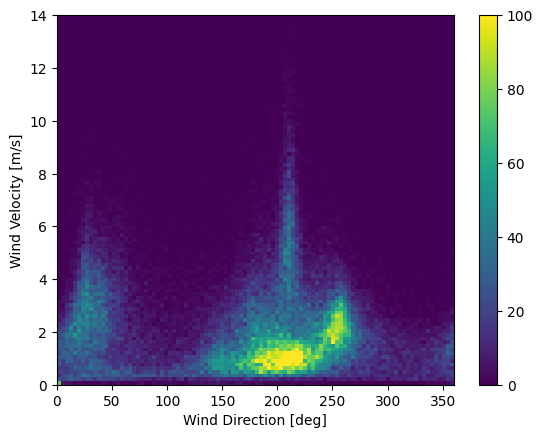

In [11]:
plt.hist2d(df['wd (deg)'], df['wv (m/s)'], bins=(100, 100), vmax=100)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')
plt.show()

However, if we convert the wind direction and wind velocity columns into a wind **vector**, the distribution becomes simpler for the model.

We visualize the distribution of the X and Y components of the wind vector.


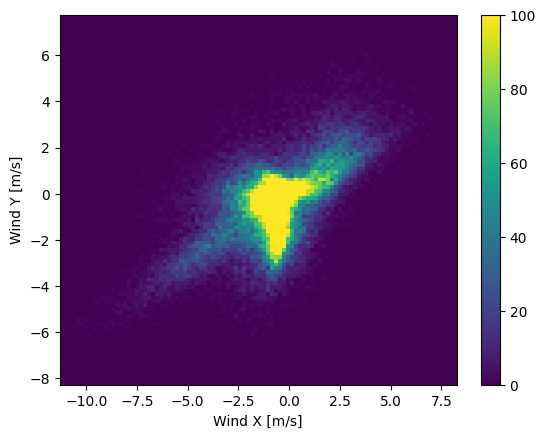

In [12]:
wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')

# convert to radians
wd_rad = df.pop('wd (deg)')*np.pi / 180

# compute the x and y components of the wind velocity vector
df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)

# compute the x and y components of the maximum wind velocity vector
df['max Wx'] = max_wv*np.cos(wd_rad)
df['max Wy'] = max_wv*np.sin(wd_rad)

plt.hist2d(df['Wx'], df['Wy'], bins=(100, 100), vmax=100)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')
plt.show()


In the previous angle plot, information that should be "close" was discontinuous at the right and left edges. However, as shown in the vector distribution above, that is no longer the case.


### Time


Just like the wind-direction angle information, the `Date Time` column is very convenient for humans but is hard for the model to handle.


For example, 59 and 0 differ by 59 as plain numbers, but as time information, one second after 10:59:59 is 11:00:00.

So we decide to convert it to seconds.


In [13]:
timestamp_s = date_time.map(pd.Timestamp.timestamp)

Furthermore, the data we handle in this time-series forecasting task is weather data, so it has clear daily and yearly periodicity.


There are various ways to handle periodicity; here we convert it into clear "Time of day" (daily cycle) and "Time of year" (yearly cycle) signals using sin and cos.


In [14]:
day = 24*60*60
year = (365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)).values
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)).values
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year)).values
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year)).values

Text(0.5, 1.0, 'Time of day signal')

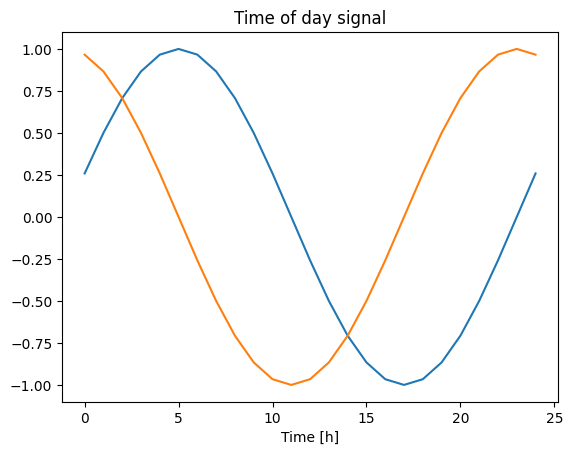

In [15]:
plt.plot(np.array(df['Day sin'])[:25])
plt.plot(np.array(df['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

By performing this kind of processing, the model can access most of the important frequency features (the daily and yearly cycles).

In the case of this data, the fact that it is "weather data" allowed us to anticipate in advance which cycles would be important.

When such information is not available, you can extract features with a <a href="https://en.wikipedia.org/wiki/Fast_Fourier_transform" class="external">fast Fourier transform</a> and determine which frequencies are important. To confirm our expectation, the `tf.signal.rfft` of the temperature over time is shown below. Clear peaks can be observed at frequencies close to `1/year` and `1/day`.


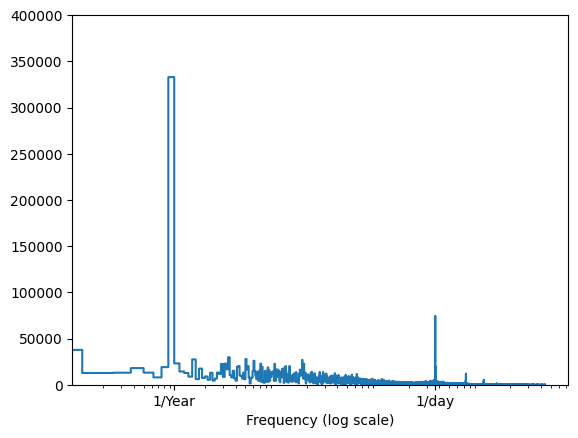

In [16]:
fft = tf.signal.rfft(df['T (degC)'])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df['T (degC)'])
hours_per_year = 24*365.2524
years_per_dataset = n_samples_h/(hours_per_year)

f_per_year = f_per_dataset/years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.ylim(0, 400000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 365.2524], labels=['1/Year', '1/day'])
_ = plt.xlabel('Frequency (log scale)')

### Drawing the line chart


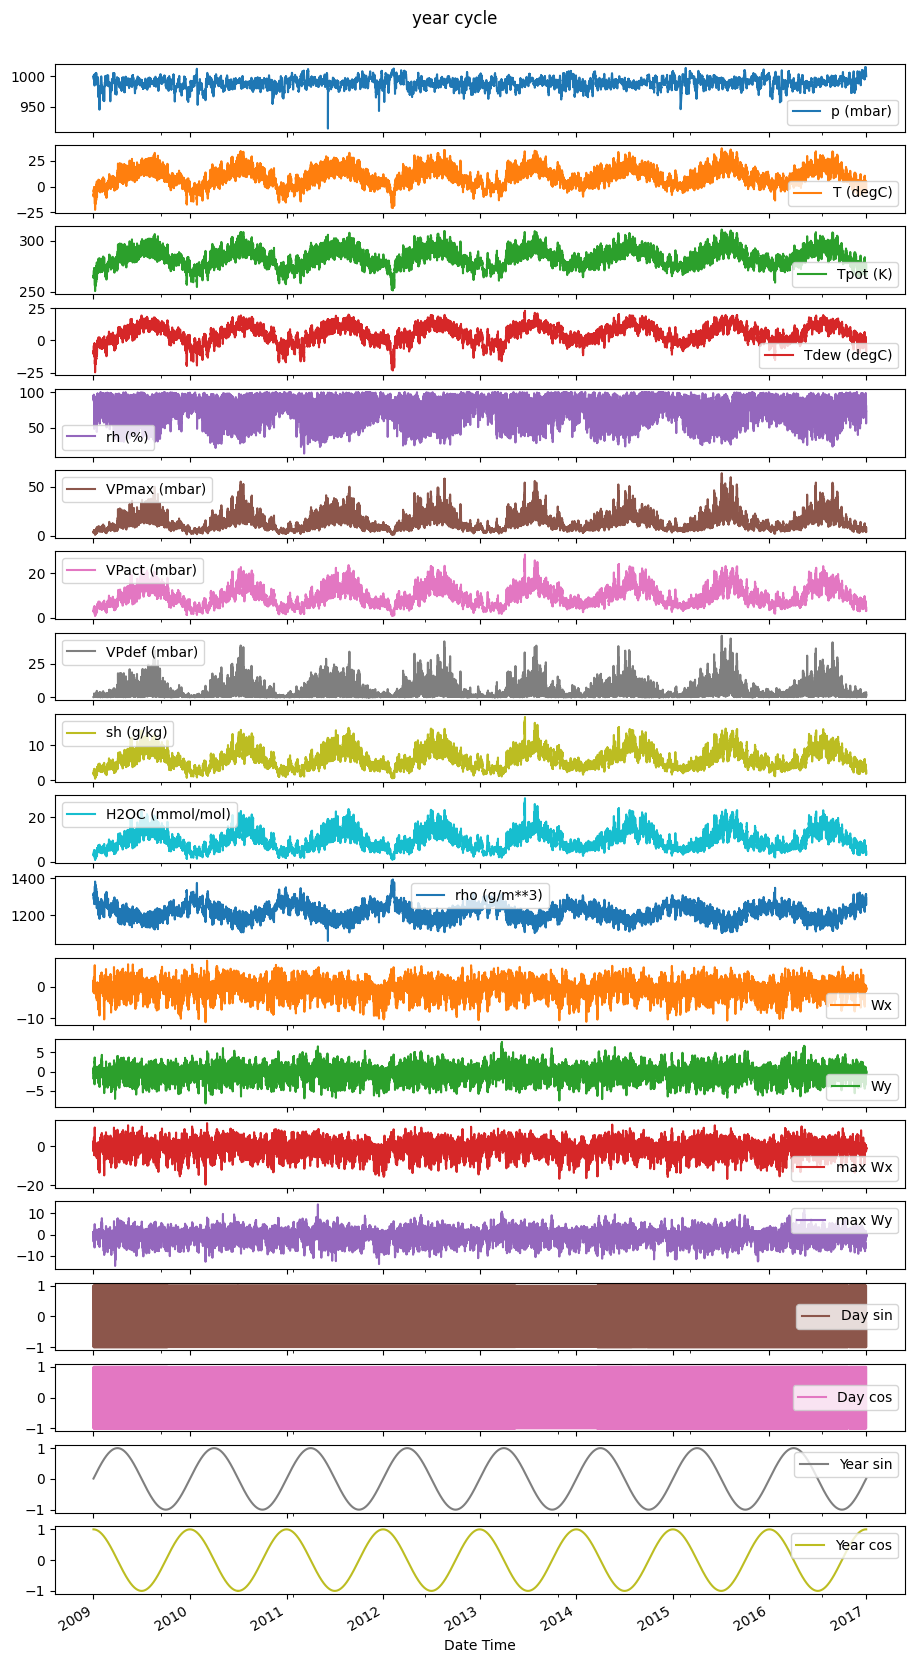

In [17]:
# Draw a line chart of all the data

plot_features = df
plot_features.index = date_time
plot_features.plot(subplots=True, title='year cycle', kind='line',  figsize=(10,18))
plt.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.95)
plt.show()

## Data to be input to the model (after feature engineering)


Let's review the data after feature engineering.
This is the input/output data for the model.

|Column number|Column name|Meaning|Overview|
|----|----|----|---|
|[index]|Date Time|Date/time|Observation date and time (1-hour intervals)|
|0|p (mbar)| Atmospheric pressure (mbar)|The force that gas molecules in the atmosphere exert on Earth's surface (the pressure caused by the weight of the atmosphere)|
|1|T (degC)| Temperature (°C)|An index representing the speed of motion and the energy state of the molecules and atoms of a substance|
|2|Tpot (K)|Potential temperature (K)|A temperature index based on a reference pressure (a temperature index that is robust to changes in pressure)|
|3|Tdew (degC) |Dew point temperature (°C)|The temperature at which the water vapor in the air reaches saturation (the temperature at which some of the water vapor turns into liquid)|
|4|rh (%) |Relative humidity (%)|The ratio of the amount of water vapor contained in the air at a given temperature to the saturation water vapor amount at that temperature|
|5|VPmax (mbar) |Saturation vapor pressure (mbar)|An index showing the pressure of the water vapor when the water vapor in the air reaches saturation at a specific temperature|
|6|VPact (mbar) |Actual vapor pressure (mbar)|An index showing the pressure of the water vapor in the air|
|7|VPdef (mbar)|Vapor pressure deficit (mbar)|The value obtained by subtracting the actual vapor pressure (VPact) from the saturation vapor pressure (VPmax)|
|8|sh (g/kg)| Specific humidity (g/kg)|The mass of water vapor in the atmosphere divided by the mass of the air|
|9|H2OC (mmol/mol) |Water vapor concentration (mole fraction)|The number of water vapor molecules divided by the total number of molecules in the air (an index showing the proportion of the air that water vapor occupies)|
|10|rho (g/m**3) |Density (g/m³)|An index showing the mass of air molecules and gaseous components in the atmosphere per unit volume|
|11|Wx|x component of the wind velocity vector|An index representing the strength and direction of the wind|
|12|Wy |y component of the wind velocity vector|An index representing the strength and direction of the wind|
|13|max Wx|x component of the maximum wind velocity vector|An index representing the strength and direction of the fastest wind observed within a specific time window|
|14|max Wy |y component of the maximum wind velocity vector|An index representing the strength and direction of the fastest wind observed within a specific time window|
|15|Day sin |Daily periodic component (sin)|A column to make the daily periodicity easier for the model to access|
|16|Day cos |Daily periodic component (cos)|A column to make the daily periodicity easier for the model to access|
|17|Year sin |Yearly periodic component (sin)|A column to make the yearly periodicity easier for the model to access|
|18|Year cos |Yearly periodic component (cos)|A column to make the yearly periodicity easier for the model to access|



## Splitting the dataset

We split the data into a training dataset, a validation dataset, and a test dataset.
Because we predict future data from past data, we split it in chronological order.


In [18]:

column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
valid_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

print("Training data (first 5 rows)")
display(train_df.head(5))
print()
print("Validation data (first 5 rows)")
display(valid_df.head(5))
print()
print("Test data (first 5 rows)")
display(test_df.head(5))


Training data (first 5 rows)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,
2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,-0.204862,-0.046168,-0.614587,-0.138503,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,-0.245971,-0.044701,-0.619848,-0.112645,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,-0.050000,-0.086603,-0.190000,-0.329090,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,-0.368202,0.156292,-0.810044,0.343843,0.965926,0.258819,0.012916,0.999917



Validation data (first 5 rows)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,
2014-08-05 02:10:00,990.43,14.46,288.41,13.81,95.9,16.49,15.82,0.68,9.99,15.97,1192.35,-0.448741,-1.389328,-0.682332,-2.112540,0.537300,0.843391,-0.549225,-0.835674
2014-08-05 03:10:00,990.66,13.83,287.76,13.39,97.2,15.83,15.39,0.44,9.72,15.53,1195.44,-0.449278,-0.756670,-0.714760,-1.203793,0.737277,0.675590,-0.549824,-0.835280
2014-08-05 04:10:00,990.80,13.53,287.45,13.31,98.6,15.53,15.31,0.22,9.67,15.45,1196.90,-1.518657,0.592100,-2.608735,1.017103,0.887011,0.461749,-0.550423,-0.834886
2014-08-05 05:10:00,990.96,13.33,287.24,13.16,98.9,15.33,15.16,0.17,9.57,15.29,1198.00,-0.768007,-0.855958,-1.175385,-1.309988,0.976296,0.216440,-0.551021,-0.834491
2014-08-05 06:10:00,991.10,13.46,287.35,13.35,99.3,15.46,15.35,0.11,9.69,15.49,1197.54,-1.443201,-0.220841,-2.253766,-0.344875,0.999048,-0.043619,-0.551619,-0.834096



Test data (first 5 rows)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,
2016-03-11 20:00:00,1001.93,2.80,275.81,1.25,89.5,7.47,6.69,0.78,4.16,6.68,1261.61,2.674455,1.336933,3.908819,1.953979,-8.660254e-01,0.500000,0.937670,0.347527
2016-03-11 21:00:00,1002.38,2.75,275.72,0.67,86.1,7.45,6.41,1.04,3.99,6.40,1262.54,2.836975,0.944286,4.943357,1.645394,-7.071068e-01,0.707107,0.937919,0.346855
2016-03-11 22:00:00,1002.63,2.46,275.41,0.46,86.6,7.29,6.32,0.98,3.93,6.30,1264.24,2.748864,1.298208,3.553630,1.678276,-5.000000e-01,0.866025,0.938167,0.346183
2016-03-11 23:00:00,1002.48,1.93,274.90,0.82,92.3,7.03,6.48,0.54,4.03,6.47,1266.37,1.506908,1.919070,2.352999,2.996580,-2.588190e-01,0.965926,0.938415,0.345510
2016-03-12 00:00:00,1002.42,1.87,274.84,0.76,92.3,6.99,6.45,0.54,4.01,6.44,1266.63,3.037622,1.614452,4.565263,2.426371,-1.801868e-12,1.000000,0.938662,0.344837


## Standardizing the data


In a neural network (NN), if the magnitudes of the values differ greatly from one data column (type) to another, the network ends up placing more weight on the columns with larger values.

```
Example: a person's height [cm] and weight [kg]

If there is a column storing height recorded in cm and a column storing weight recorded in kg, the values in the height column will tend to be larger overall.
If you train a neural network on such data as is, it will tend to learn by placing more weight on the height information, which has larger values.
```

To prevent this kind of situation, when training a neural network it is necessary to align the magnitudes of the values in each column (scaling). Standardization is a scaling method that makes the mean 0 and the variance 1.

$$ x_{std}  = \frac{x - \bar{x}}{s}$$
$x$ is the data before standardization (each column), $ \bar{x} $ is the mean of $x$, $s$ is the standard deviation of $x$, and $x_{std}$ is the data after standardization.


In [19]:
# Display the first 5 rows of the dataset before standardization
display(train_df.head(5))


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,
2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,-0.204862,-0.046168,-0.614587,-0.138503,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,-0.245971,-0.044701,-0.619848,-0.112645,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,-0.050000,-0.086603,-0.190000,-0.329090,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,-0.368202,0.156292,-0.810044,0.343843,0.965926,0.258819,0.012916,0.999917


In [20]:
# Standardization

scaler = StandardScaler()
# Standardization requires a mean and a standard deviation.
# Here we use the mean and standard deviation of the training dataset to
# standardize the training / validation / test datasets.
scaler.fit(train_df)

train_col = train_df.columns
train_idx = train_df.index
valid_col = valid_df.columns
valid_idx = valid_df.index
test_col = test_df.columns
test_idx = test_df.index


train_df = pd.DataFrame( scaler.transform(train_df), columns = train_col, index = train_idx )
valid_df = pd.DataFrame( scaler.transform(valid_df), columns = valid_col, index = valid_idx )
test_df = pd.DataFrame( scaler.transform(test_df), columns = test_col, index = test_idx )


# Display the first 5 rows of the dataset after standardization
display(train_df.head(5))


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,,,,,,,,,,,,,,
2009-01-01 01:00:00,0.945317,-1.982493,-2.041909,-1.918992,1.117113,-1.302864,-1.477338,-0.790432,-1.480051,-1.482712,2.218546,0.193411,0.221164,0.111142,0.217930,0.366114,1.366083,-0.061053,1.428449
2009-01-01 02:00:00,0.959780,-2.078393,-2.138188,-2.060985,1.044628,-1.330156,-1.534370,-0.786280,-1.536205,-1.539050,2.325731,0.172989,0.222103,0.109459,0.227801,0.707207,1.224807,-0.060030,1.428438
2009-01-01 03:00:00,0.986294,-2.070305,-2.132457,-2.045208,1.062749,-1.328857,-1.527241,-0.788356,-1.528718,-1.532008,2.324022,0.207985,0.276269,0.111219,0.324082,1.000110,1.000069,-0.059007,1.428427
2009-01-01 04:00:00,1.004372,-2.098035,-2.161112,-2.096841,1.008386,-1.336654,-1.546251,-0.782129,-1.547436,-1.553135,2.358937,0.270346,0.195269,0.246910,0.145177,1.224862,0.707186,-0.057984,1.428415
2009-01-01 05:00:00,1.061016,-2.165050,-2.232175,-2.187200,0.984224,-1.353549,-1.579519,-0.782129,-1.581129,-1.585998,2.446345,0.112265,0.350822,0.048641,0.402057,1.366147,0.366116,-0.056961,1.428402


## Windowing the data

Our model makes predictions for a future interval based on a window (a window/segment) of consecutive sample points of the time-series data.

The main characteristics of the input window are as follows.

- The width of the input window and the width of the label window (the number of time steps)
- Their time offset (the position of the interval to be predicted relative to the interval used for training)
- Which features are used as input data, as ground-truth labels, or as both


For example,
* To make a single prediction 24 hours ahead using the past 24 hours of history, the window definition is
![Window example 1](https://www.tensorflow.org/static/tutorials/structured_data/images/raw_window_24h.png, "Make a single prediction 24 hours ahead from the past 24 hours of data")

* To make a single prediction 1 hour ahead using the past 6 hours of history, the window definition is
![Window example 2](https://www.tensorflow.org/static/tutorials/structured_data/images/raw_window_1h.png, "Make a single prediction 24 hours ahead from the past 24 hours of data")




To implement functionality that makes this kind of data windowing easy, we define a ```WindowGenerator``` class. It has the following capabilities.

1. Process the index and offset as in the figures above.
2. Split a window of features into `(features, labels)` pairs.
3. Plot the contents of the resulting windows.
4. Efficiently generate batches of these windows from the training, validation, and test data using `tf.data.Dataset`.


In [21]:
class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                train_df=train_df, valid_df=valid_df, test_df=test_df,
                batch_size=32, label_columns=None):

        # store the input data
        self.train_df = train_df
        self.valid_df = valid_df
        self.test_df = test_df

        # store the batch size specified by batch_size
        self.batch_size = batch_size

        # store the indices of the columns specified by label_columns
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in
                                            enumerate(label_columns)}
        self.column_indices = {name: i for i, name in
                            enumerate(train_df.columns)}

        # store the window parameters
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_indices}',
            f'Label indices: {self.label_indices}',
            f'Label column name(s): {self.label_columns}'])

    # Given a list of consecutive inputs, convert them into an input window and a label window.
    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1)


        # Slicing does not preserve static shape information, so set the shape manually
        # (so that the shape information can be used by tf.data.Datasets).
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])

        return inputs, labels

    # Take a time-series DataFrame and, using the
    # tf.keras.utils.timeseries_dataset_from_array function,
    # convert it into a tf.data.Dataset of (input_window, label_window) pairs.
    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=True,
            batch_size=self.batch_size)

        ds = ds.map(self.split_window)
        return ds

    # For drawing/visualizing the split windows
    def plot(self, model=None, plot_col='T (degC)', max_subplots=3):
        inputs, labels = self.example
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices[plot_col]
        max_n = min(max_subplots, len(inputs))
        for n in range(max_n):
            plt.subplot(max_n, 1, n+1)
            plt.ylabel(f'{plot_col} [normed]')
            plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                    label='Inputs', marker='.', zorder=-10)

            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index

            if label_col_index is None:
                continue

            plt.scatter(self.label_indices, labels[n, :, label_col_index],
                        edgecolors='k', label='Labels', c='#2ca02c', s=64)
            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                            marker='X', edgecolors='k', label='Predictions',
                            c='#ff7f0e', s=64)

            if n == 0:
                plt.legend()
        plt.xlabel('Time [h]')



    @property
    def train(self):
        return self.make_dataset(self.train_df)

    @property
    def valid(self):
        return self.make_dataset(self.valid_df)

    @property
    def test(self):
        return self.make_dataset(self.test_df)

    @property
    def example(self):
        # Get and cache a sample batch of (inputs, labels) for plotting.
        result = getattr(self, '_example', None)
        if result is None:
            # If the contents of result (the sample batch) could not be obtained:
            # get a batch from the `.train` dataset.
            result = next(iter(self.train))
            # Cache it for next time.
            self._example = result
        return result


The output looks like this.

* To make a single prediction 24 hours ahead using the past 24 hours of history, the window definition is
![Window example 1](https://www.tensorflow.org/static/tutorials/structured_data/images/raw_window_24h.png, "Make a single prediction 24 hours ahead from the past 24 hours of data")


In [22]:
# Window definition for making a single prediction 24 hours ahead using the past 24 hours of history
w1 = WindowGenerator(input_width=24, label_width=1, shift=24,
                     label_columns=['T (degC)'])
display(w1)


Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['T (degC)']

* To make a single prediction 1 hour ahead using the past 6 hours of history, the window definition is
![Window example 2](https://www.tensorflow.org/static/tutorials/structured_data/images/raw_window_1h.png, "Make a single prediction 24 hours ahead from the past 24 hours of data")


In [23]:
# Window definition for making a single prediction 1 hour ahead using the past 6 hours of history
w2 = WindowGenerator(input_width=6, label_width=1, shift=1,
                     label_columns=['T (degC)'])
display(w2)


Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['T (degC)']

Given a list of consecutive inputs, the `split_window` method converts them into an input window and a label window.

The previously defined example `w2` is split as follows.

![All windows are consecutive samples, which are split into (inputs, labels) pairs](https://www.tensorflow.org/static/tutorials/structured_data/images/split_window.png, "All windows are consecutive samples, which are split into (inputs, labels) pairs")

This figure does not show the `features` axis of the data, but because this `split_window` function also handles `label_columns`, it can be used for either single-output or multi-output cases.


In the next cell, we provide a list of consecutive inputs.


In [24]:
# Stack 3 slices, each equal to the total window length
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 19)
Inputs shape: (3, 6, 19)
Labels shape: (3, 1, 1)


Normally, in TensorFlow data the outermost index is an array spanning the whole sample (this is the "batch size" dimension).

The middle index is the "time" or "space" (width, height) dimension.

And the innermost index is the number of feature types.

The code above took a batch size of 3, a step window width of 7 hours, and 19 features at each time step.

It split this into 6 time steps with 19 input features, and 1 time step with 1 feature as the ground-truth label.

<br>

The ground-truth labels are specified by ```label_columns``` of the ```WindowGenerator```. In w2 above we set ```label_columns=['T (degC)']```, so only the temperature column was used as the ground-truth label.

From here on, we specify all of the features (19 columns) as ground-truth labels.


Now that the ```WindowGenerator``` object lets us access ```tf.data.Dataset``` objects, we can easily output data with the specified window width.

With ```Dataset.element_spec``` we can check the structure, data types, and shapes of the dataset elements.


In [25]:
# It is an (input, ground-truth label) pair.
display(w2.train.element_spec)


(TensorSpec(shape=(None, 6, 19), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

In [26]:
# Iterating over the Dataset (e.g., with a for loop) generates batches.
for example_inputs, example_labels in w2.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')


Inputs shape (batch, time, features): (32, 6, 19)
Labels shape (batch, time, features): (32, 1, 1)


## Single-time-step model


The simplest model we can build with this kind of time-series data is one that predicts the value of a single feature one time step (1 hour) ahead based only on the current conditions.

In other words, it is a model that predicts the temperature ``` T (degC) ``` 1 hour ahead.


![Single-step model](https://www.tensorflow.org/static/tutorials/structured_data/images/narrow_window.png, "Single-step model")


However, if there is only one prediction sample, it is hard to tell from a plot whether the prediction is good or bad, so we create a ``` WindowGenerator ``` that generates a window of 24 consecutive hours of inputs and labels at once.

The model still makes a prediction 1 hour ahead based on a single input time step.
Each prediction is an independent prediction with no interaction between time steps.


![Single-step model (24 consecutive hours)](https://www.tensorflow.org/static/tutorials/structured_data/images/lstm_many_window.png, "Single-step model (24 consecutive hours)")


Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos']


Check the shape of the input data
Inputs shape (batch, time, features): (512, 24, 19)
Labels shape (batch, time, features): (512, 24, 19)


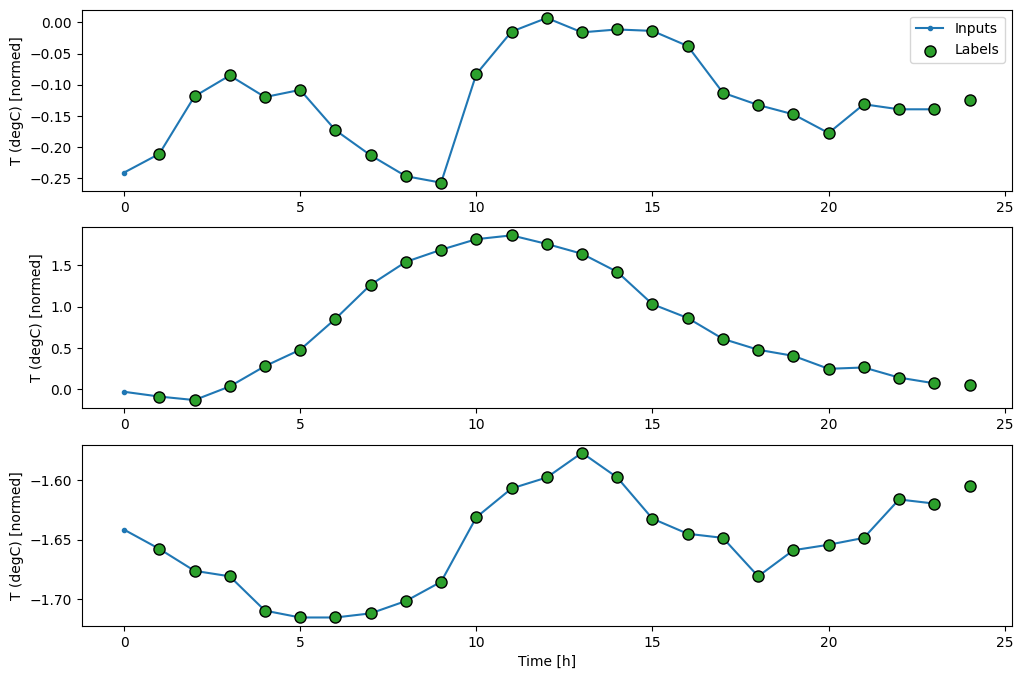

In [27]:
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1, \
    batch_size=512, label_columns=['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy',
       'Day sin', 'Day cos', 'Year sin', 'Year cos'])

# Here we plot only the temperature column.
wide_window.plot(plot_col='T (degC)')
display(wide_window)

print("\nCheck the shape of the input data")
for example_inputs, example_labels in wide_window.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')


### Defining the RNN model


In [28]:

# input layer: (time × features channels)
inputs = tf.keras.layers.Input(shape = (24, num_features), name = 'input')

# (batch_size, time, features) -> (batch_size, time, rnn_units)
x = tf.keras.layers.SimpleRNN(units=32, return_sequences=True, name='rnn')(inputs)

# (batch, time, rnn_units) ->  (batch, time, features)
outputs = tf.keras.layers.Dense( units= num_features )(x)

# Define the model
model = tf.keras.Model( inputs = inputs, outputs = outputs, name = 'rnn_model' )

# Print the model structure as text
model.summary()


Model: "rnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 19)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ (None, 24, 32)         │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24, 19)         │           627 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,291 (8.95 KB)

 Trainable params: 2,291 (8.95 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Prepare to create a log file during training
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log_single.csv'))


# Compile the model (set the optimization algorithm, loss function, evaluation metrics, etc.)
# We will study loss functions in Section 2.6.
model.compile(loss=tf.losses.MeanSquaredError(), # loss function
                   optimizer=tf.optimizers.Adam(), # optimization algorithm
                   metrics=[tf.metrics.MeanAbsoluteError(),# monitoring metrics (they do not affect the training of the model itself)
                            tf.metrics.MeanAbsolutePercentageError(),
                            ])

history = model.fit(wide_window.train,
                    epochs = 10,
                    validation_data = wide_window.valid,
                    callbacks = callbacks
                    )


Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - loss: 0.5822 - mean_absolute_error: 0.5658 - mean_absolute_percentage_error: 1125.6797 - val_loss: 0.2630 - val_mean_absolute_error: 0.3782 - val_mean_absolute_percentage_error: 2694.5010
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.1911 - mean_absolute_error: 0.3137 - mean_absolute_percentage_error: 751.5435 - val_loss: 0.1485 - val_mean_absolute_error: 0.2669 - val_mean_absolute_percentage_error: 2057.5854
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.1307 - mean_absolute_error: 0.2472 - mean_absolute_percentage_error: 573.3654 - val_loss: 0.1164 - val_mean_absolute_error: 0.2262 - val_mean_absolute_percentage_error: 1616.7191
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 0.1089 - mean_absolute_error: 0.2169 - mean_absolute_percentage_error: 474.6924 - val_loss: 0.1005 - val_mean_absolute_error: 0.2024 - val_mean_absolute_percentage_error: 1305.8265
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 

### Plotting the loss function and evaluation metrics over the course of training


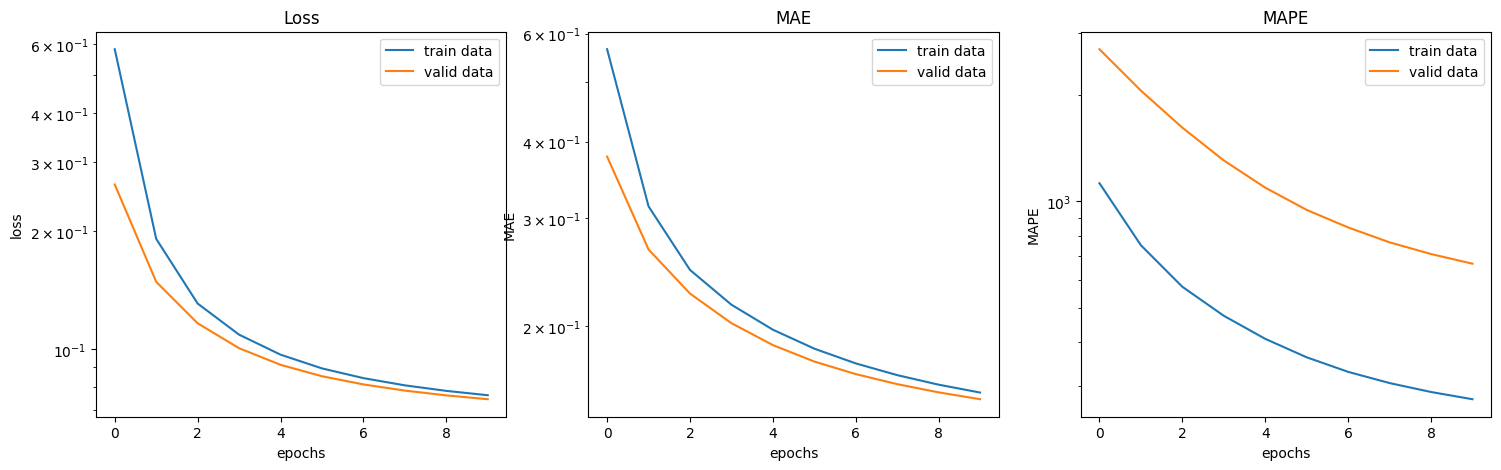

In [30]:
log_df = pd.read_csv('training_log_single.csv')

epochs = log_df["epoch"].values

train_loss = log_df["loss"].values
train_mae = log_df['mean_absolute_error'].values
train_mape = log_df['mean_absolute_percentage_error'].values

valid_loss = log_df["val_loss"].values
valid_mae = log_df['val_mean_absolute_error'].values
valid_mape = log_df['val_mean_absolute_percentage_error'].values


fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")
axes[0].set_yscale("log")

axes[1].plot(epochs, train_mae, label="train data")
axes[1].plot(epochs, valid_mae, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("MAE")
axes[1].legend(loc="upper right")
axes[1].set_title("MAE")
axes[1].set_yscale("log")


axes[2].plot(epochs, train_mape, label="train data")
axes[2].plot(epochs, valid_mape, label="valid data")
axes[2].set_xlabel("epochs")
axes[2].set_ylabel("MAPE")
axes[2].legend(loc="upper right")
axes[2].set_title("MAPE")
axes[2].set_yscale("log")


plt.show()

### Visualizing the inference results


96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.0754 - mean_absolute_error: 0.1540 - mean_absolute_percentage_error: 269.6256
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0745 - mean_absolute_error: 0.1521 - mean_absolute_percentage_error: 666.4489


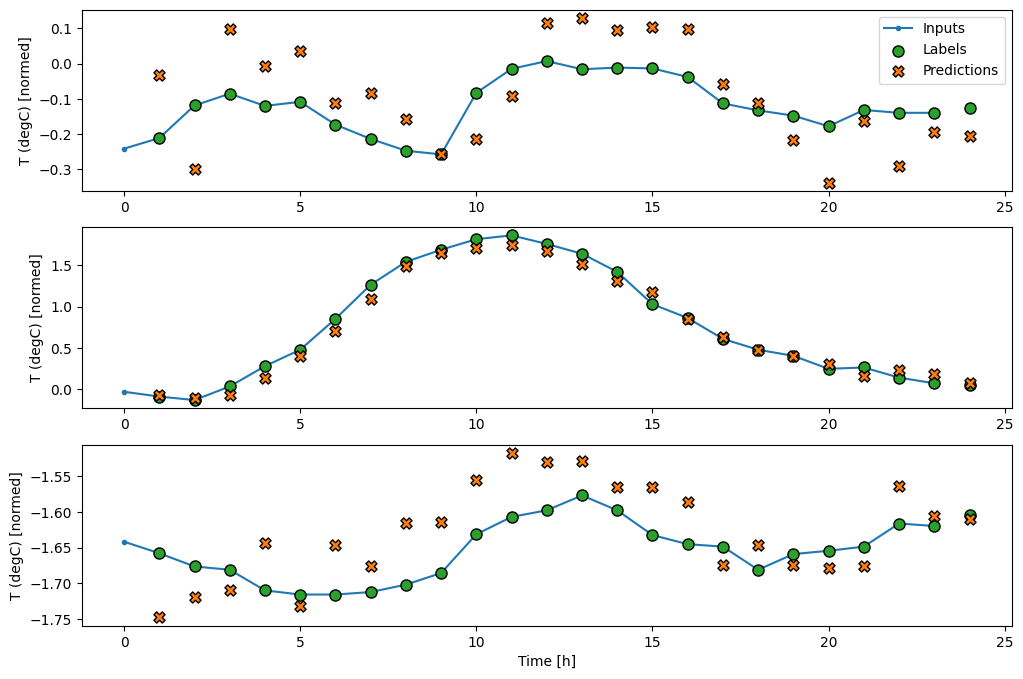

In [31]:
train_performance = {}
valid_performance = {}
test_performance = {}

train_performance['RNN(single step)'] = model.evaluate( wide_window.train, return_dict=True)
valid_performance['RNN(single step)'] = model.evaluate( wide_window.valid, return_dict=True)
test_performance['RNN(single step)'] = model.evaluate( wide_window.test, return_dict=True, verbose=0)
# Here we visualize only the temperature column
wide_window.plot(model, plot_col='T (degC)')


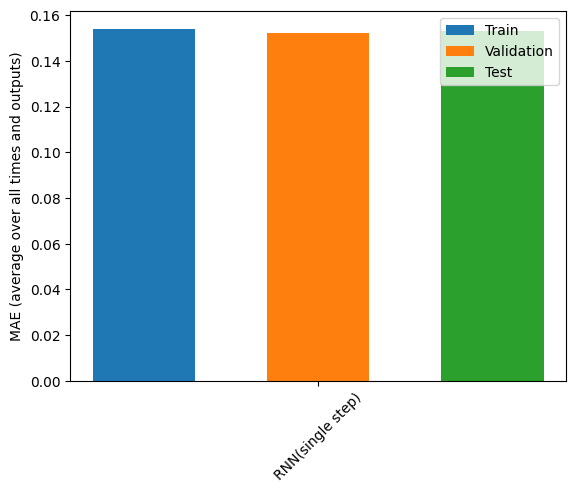

In [32]:
x = np.arange(len(train_performance))
width = 0.1

metric_name = 'mean_absolute_error'

train_mae = [v[metric_name] for v in train_performance.values()]
valid_mae = [v[metric_name] for v in valid_performance.values()]
test_mae = [v[metric_name] for v in test_performance.values()]

plt.bar(x - 0.17, train_mae, width, label='Train')
plt.bar(x, valid_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=train_performance.keys(),
           rotation=45)
plt.ylabel(f'MAE (average over all times and outputs)')
_ = plt.legend()

## Multi-time-step model (single shot)

So far, we have made single-time-step predictions up to 1 hour ahead.


However, there is not much demand for "weather forecast data 1 hour ahead."


You yourselves probably look at the "morning" news to see the "evening/nighttime weather forecast" and decide whether to take an umbrella or a jacket, don't you?


From here, we extend the single-time-step model to create a multi-time-step model.

In multi-step prediction, the model must learn to predict a range of future values. Therefore, unlike a single-step model that predicts only a single future data point, a multi-step model predicts a sequence of future data points.

There are broadly two approaches to this.

**(1) Single-shot prediction, which predicts the entire time series at once**<br>
**(2) Autoregressive prediction, in which the model makes a single-step prediction and uses its output (the model's predicted value) as the next input**

<br>

---

<br>

(1) In the multi-step (single-shot) model, the training data consists of hourly data points, but here the model learns to predict 24 hours ahead given the past 24 hours of data.

![Multi-step (single shot)](https://www.tensorflow.org/static/tutorials/structured_data/images/multistep_lstm.png, "Multi-step (single shot)")


The next code cell is a Window object that generates these slices from the dataset.


Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
Label column name(s): ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos']

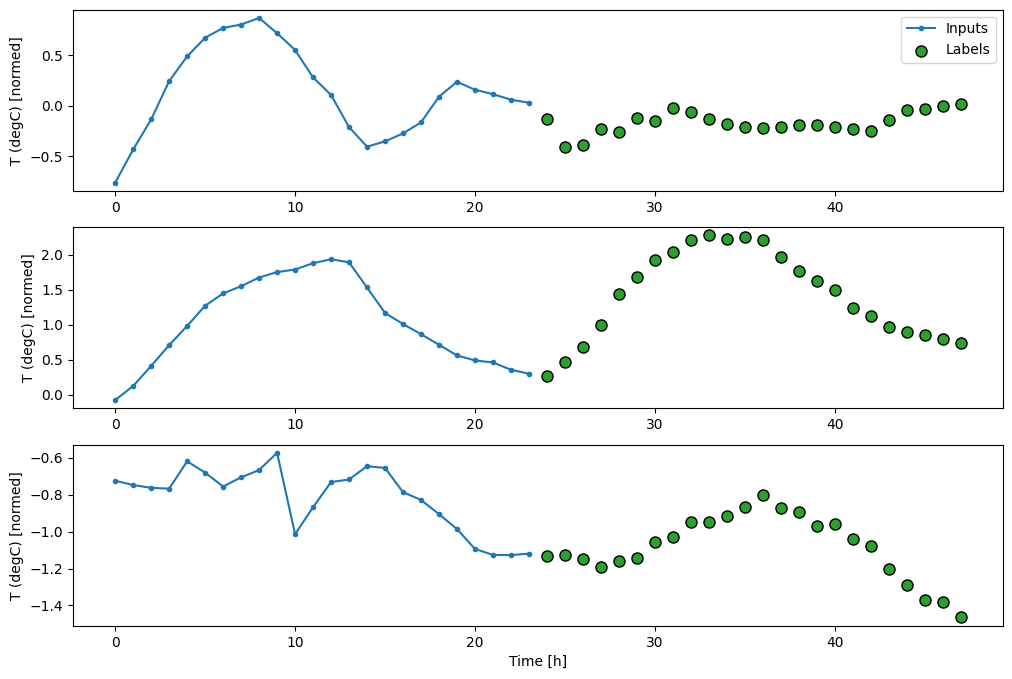

In [33]:
OUT_STEPS = 24
multi_window = WindowGenerator(input_width=24,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS,
                               batch_size=512,
                               label_columns=['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy',
       'Day sin', 'Day cos', 'Year sin', 'Year cos']
                               )

# Here we plot only the temperature column.
multi_window.plot(plot_col='T (degC)')
multi_window


### Defining the RNN model (single shot)


In [34]:
# input layer: (batch × time × features channels)
inputs = tf.keras.layers.Input(shape = (24, num_features), name = 'input')

#  (batch, time, features) -> (batch, time, rnn_units)
x = tf.keras.layers.SimpleRNN(units=32, return_sequences=False, name='rnn')(inputs)

# (batch, time, rnn_units) -> (batch, time, out_steps*features)
x = tf.keras.layers.Dense(units = OUT_STEPS * num_features, \
                          kernel_initializer=tf.initializers.zeros())(x)

# (batch, time, out_steps*features) -> (batch, out_steps, features)
outputs = tf.keras.layers.Reshape([OUT_STEPS, num_features])(x)

# Define the model
multi_step_model = tf.keras.Model(inputs = inputs, outputs = outputs, name = 'rnn_multi_step_model' )

# Print the model structure as text
multi_step_model.summary()


Model: "rnn_multi_step_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 19)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ (None, 32)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 456)            │        15,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24, 19)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,712 (65.28 KB)

 Trainable params: 16,712 (65.28 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Prepare to create a log file during training
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log_multi.csv'))

# Compile the model (set the optimization algorithm, loss function, evaluation metrics, etc.)
# We will study loss functions in Section 2.6.
multi_step_model.compile(loss=tf.losses.MeanSquaredError(), # loss function
                   optimizer=tf.optimizers.Adam(), # optimization algorithm
                   metrics=[tf.metrics.MeanAbsoluteError(),# monitoring metrics (they do not affect the training of the model itself)
                            tf.metrics.MeanAbsolutePercentageError(),
                            ])

history = multi_step_model.fit(multi_window.train,
                         epochs = 10,
                         validation_data = multi_window.valid,
                         callbacks = callbacks
                         )



Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.5812 - mean_absolute_error: 0.5764 - mean_absolute_percentage_error: 424.1281 - val_loss: 0.3725 - val_mean_absolute_error: 0.4426 - val_mean_absolute_percentage_error: 2041.0399
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.3225 - mean_absolute_error: 0.4009 - mean_absolute_percentage_error: 602.7510 - val_loss: 0.2914 - val_mean_absolute_error: 0.3717 - val_mean_absolute_percentage_error: 1667.2998
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.2828 - mean_absolute_error: 0.3649 - mean_absolute_percentage_error: 549.7376 - val_loss: 0.2729 - val_mean_absolute_error: 0.3523 - val_mean_absolute_percentage_error: 1433.0830
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.2668 - mean_absolute_error: 0.3482 - mean_absolute_percentage_error: 508.2773 - val_loss: 0.2619 - val_mean_absolute_error: 0.3401 - val_mean_absolute_percentage_error: 1305.0989
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 

### Plotting the loss function and evaluation metrics over the course of training


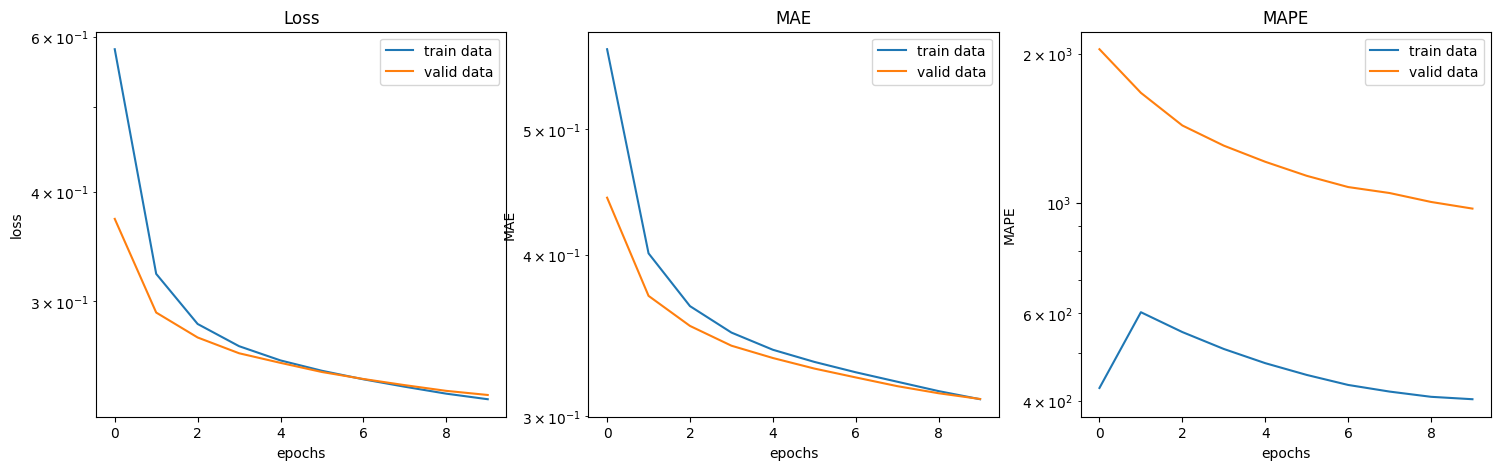

In [36]:
log_df = pd.read_csv('training_log_multi.csv')

epochs = log_df["epoch"].values

train_loss = log_df["loss"].values
train_mae = log_df['mean_absolute_error'].values
train_mape = log_df['mean_absolute_percentage_error'].values

valid_loss = log_df["val_loss"].values
valid_mae = log_df['val_mean_absolute_error'].values
valid_mape = log_df['val_mean_absolute_percentage_error'].values


fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")
axes[0].set_yscale("log")

axes[1].plot(epochs, train_mae, label="train data")
axes[1].plot(epochs, valid_mae, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("MAE")
axes[1].legend(loc="upper right")
axes[1].set_title("MAE")
axes[1].set_yscale("log")


axes[2].plot(epochs, train_mape, label="train data")
axes[2].plot(epochs, valid_mape, label="valid data")
axes[2].set_xlabel("epochs")
axes[2].set_ylabel("MAPE")
axes[2].legend(loc="upper right")
axes[2].set_title("MAPE")
axes[2].set_yscale("log")


plt.show()

### Visualizing the inference results


96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.2306 - mean_absolute_error: 0.3077 - mean_absolute_percentage_error: 405.6939
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2347 - mean_absolute_error: 0.3094 - mean_absolute_percentage_error: 974.6338


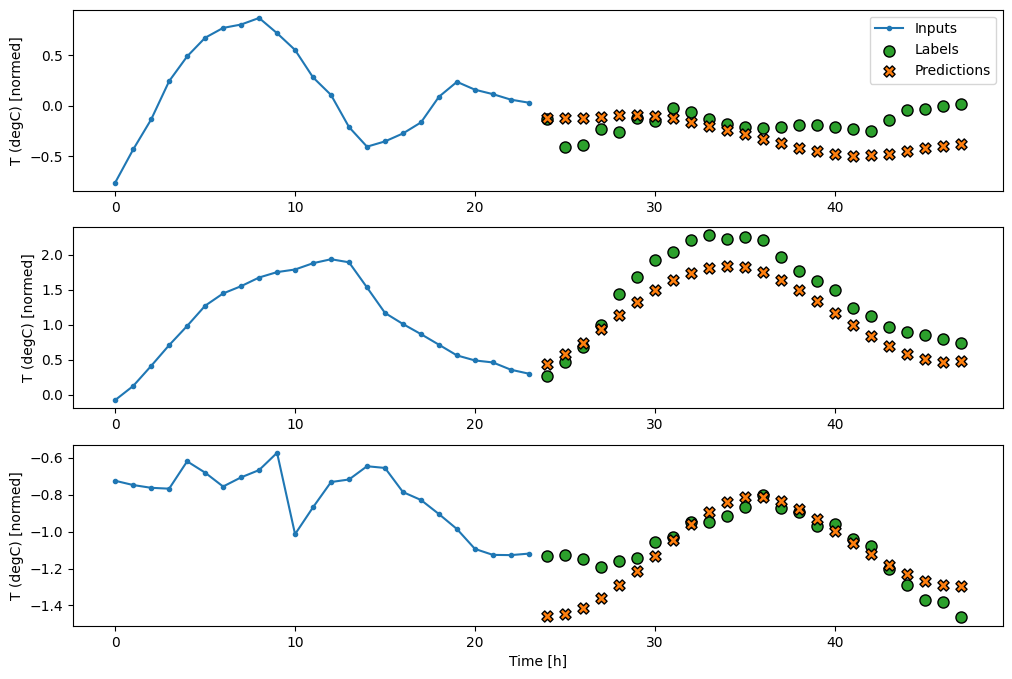

In [37]:
train_performance['RNN(multi step, single shot)'] = multi_step_model.evaluate( multi_window.train, return_dict=True)
valid_performance['RNN(multi step, single shot)'] = multi_step_model.evaluate( multi_window.valid, return_dict=True)
test_performance['RNN(multi step, single shot)'] = multi_step_model.evaluate( multi_window.test, return_dict=True, verbose=0)

# Here we plot only the temperature column.
multi_window.plot(multi_step_model, plot_col='T (degC)')


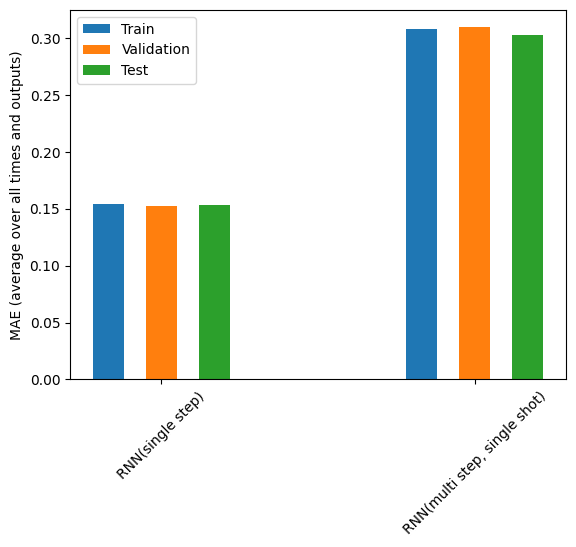

In [38]:
x = np.arange(len(train_performance))
width = 0.1

metric_name = 'mean_absolute_error'

train_mae = [v[metric_name] for v in train_performance.values()]
valid_mae = [v[metric_name] for v in valid_performance.values()]
test_mae = [v[metric_name] for v in test_performance.values()]

plt.bar(x - 0.17, train_mae, width, label='Train')
plt.bar(x, valid_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=train_performance.keys(),
           rotation=45)
plt.ylabel(f'MAE (average over all times and outputs)')
_ = plt.legend()

Compared with the RNN (single step), which uses weather data from 1 hour earlier, the accuracy of the RNN (multi step, single shot), which uses only weather data from up to 24 hours earlier, is worse.

If you collect data right up until just before the time you want to predict and train the model on it to make predictions, it is certainly easier to create an "accurate model," but in most cases there is little demand for such a model (just as there is little demand for weather data 1 hour ahead).

You also need to weigh the balance between demand and accuracy.


## Multi-time-step model (autoregressive / AutoRegressive)


Up to here, all of the models predict the entire output interval in a single step.

In some cases, decomposing the model's prediction into individual time steps may help with the prediction.

You can use each model output as the next input at each step, making the prediction for the next step based on the predicted value of the previous step.

A model of this type also has the advantage that it can be built to produce outputs of different lengths.

![Multi-step model (autoregressive)](https://www.tensorflow.org/static/tutorials/structured_data/images/multistep_autoregressive.png, "Multi-step model (autoregressive)")


Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
Label column name(s): ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos']

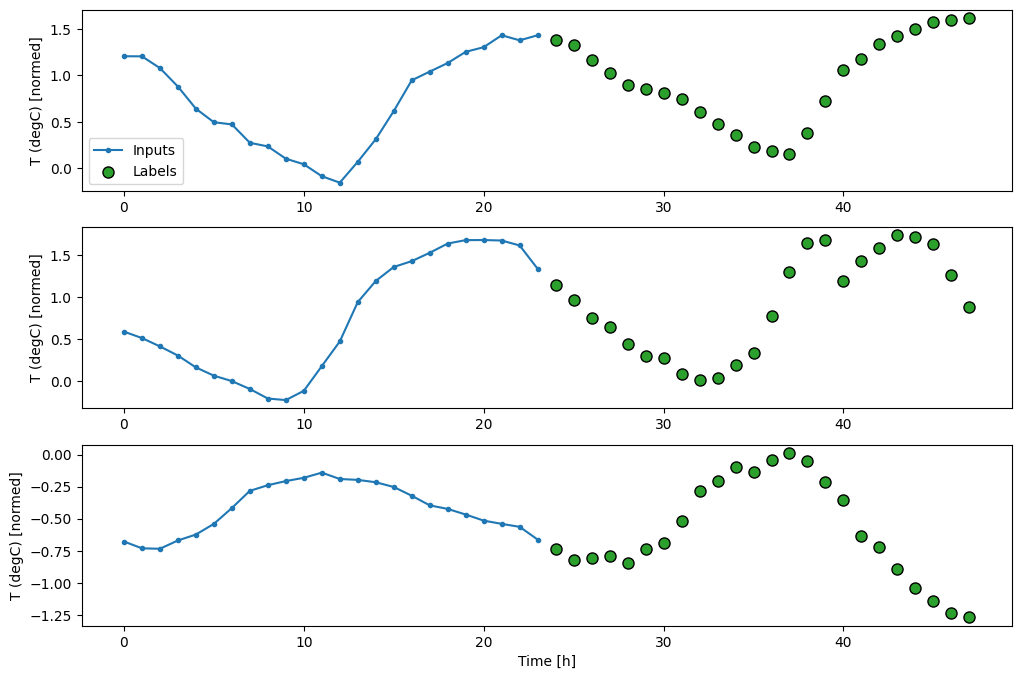

In [39]:
OUT_STEPS = 24
feedback_window = WindowGenerator(input_width=24,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS,
                               batch_size=512,
                               label_columns=['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'Wx', 'Wy', 'max Wx', 'max Wy',
       'Day sin', 'Day cos', 'Year sin', 'Year cos']
                               )

# Here we plot only the temperature column.
feedback_window.plot(plot_col='T (degC)')
feedback_window


### Defining the autoregressive model (AutoRegressive model)


In [40]:
class FeedBack(tf.keras.Model):
    def __init__(self, units, out_steps):
        super().__init__()
        self.out_steps = out_steps
        self.units = units
        self.lstm_cell = tf.keras.layers.LSTMCell(units)
        # Wrapping the LSTMCell in an RNN simplifies the `warmup` method
        self.lstm_rnn = tf.keras.layers.RNN(self.lstm_cell, return_state=True)
        self.dense = tf.keras.layers.Dense(num_features)

    def warmup(self, inputs):
        # inputs.shape -> (batch, time, features)
        # x.shape -> (batch, lstm_units)
        x, *state = self.lstm_rnn(inputs)

        # predictions.shape -> (batch, features)
        prediction = self.dense(x)
        return prediction, state

    def call(self, inputs, training=None):
        # Use a TensorArray to capture the dynamically unrolled outputs
        predictions = []
        # Initialize the LSTM state
        prediction, state = self.warmup(inputs)

        # Insert the first prediction
        predictions.append(prediction)

        # Run the remaining prediction steps
        for n in range(1, self.out_steps):
            # Use the previous prediction as input
            x = prediction
            # Run one LSTM step
            x, state = self.lstm_cell(x, states=state, training=training)
            # Convert the LSTM output into a prediction
            prediction = self.dense(x)
            # Append the prediction to the outputs
            predictions.append(prediction)

        # predictions.shape -> (time, batch, features)
        predictions = tf.stack(predictions)
        # predictions.shape -> (batch, time, features)
        predictions = tf.transpose(predictions, [1, 0, 2])
        return predictions

# Define the model
feedback_model = FeedBack(units=32, out_steps=OUT_STEPS)

feedback_model.build(input_shape=(None,24, num_features))
# Print the model structure as text
feedback_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'feed_back', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "feed_back"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_cell (LSTMCell)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Prepare to create a log file during training
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log_autoReg.csv'))

# Compile the model (set the optimization algorithm, loss function, evaluation metrics, etc.)
# We will study loss functions in Section 2.6.
feedback_model.compile(loss=tf.losses.MeanSquaredError(), # loss function
                         optimizer=tf.optimizers.Adam(),# optimization algorithm
                         metrics=[tf.metrics.MeanAbsoluteError(),# monitoring metrics (they do not affect the training of the model itself)
                                  tf.metrics.MeanAbsolutePercentageError()
                                  ])

history = feedback_model.fit(feedback_window.train,
                         epochs = 10,
                         validation_data = feedback_window.valid,
                         callbacks = callbacks
                         )


Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - loss: 0.6555 - mean_absolute_error: 0.6195 - mean_absolute_percentage_error: 516.4131 - val_loss: 0.4940 - val_mean_absolute_error: 0.5159 - val_mean_absolute_percentage_error: 1521.5735
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.4479 - mean_absolute_error: 0.4931 - mean_absolute_percentage_error: 503.8359 - val_loss: 0.3852 - val_mean_absolute_error: 0.4533 - val_mean_absolute_percentage_error: 1491.2050
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 0.3157 - mean_absolute_error: 0.4023 - mean_absolute_percentage_error: 584.7013 - val_loss: 0.2816 - val_mean_absolute_error: 0.3685 - val_mean_absolute_percentage_error: 1631.7104
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - loss: 0.2621 - mean_absolute_error: 0.3521 - mean_absolute_percentage_error: 521.7661 - val_loss: 0.2635 - val_mean_absolute_error: 0.3491 - val_mean_absolute_percentage_error: 1405.9904
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━

### Plotting the loss function and evaluation metrics over the course of training


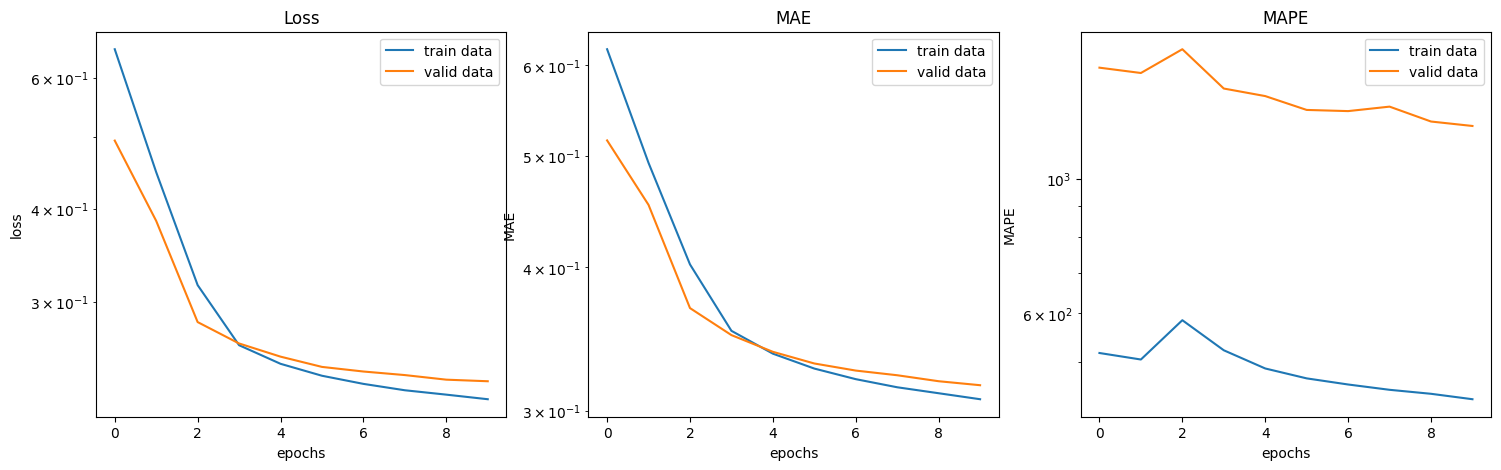

In [42]:
log_df = pd.read_csv('training_log_autoReg.csv')

epochs = log_df["epoch"].values

train_loss = log_df["loss"].values
train_mae = log_df['mean_absolute_error'].values
train_mape = log_df['mean_absolute_percentage_error'].values

valid_loss = log_df["val_loss"].values
valid_mae = log_df['val_mean_absolute_error'].values
valid_mape = log_df['val_mean_absolute_percentage_error'].values


fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")
axes[0].set_yscale("log")

axes[1].plot(epochs, train_mae, label="train data")
axes[1].plot(epochs, valid_mae, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("MAE")
axes[1].legend(loc="upper right")
axes[1].set_title("MAE")
axes[1].set_yscale("log")


axes[2].plot(epochs, train_mape, label="train data")
axes[2].plot(epochs, valid_mape, label="valid data")
axes[2].set_xlabel("epochs")
axes[2].set_ylabel("MAPE")
axes[2].legend(loc="upper right")
axes[2].set_title("MAPE")
axes[2].set_yscale("log")


plt.show()

### Visualizing the inference results


96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.2205 - mean_absolute_error: 0.3056 - mean_absolute_percentage_error: 436.1826
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.2344 - mean_absolute_error: 0.3157 - mean_absolute_percentage_error: 1220.1461


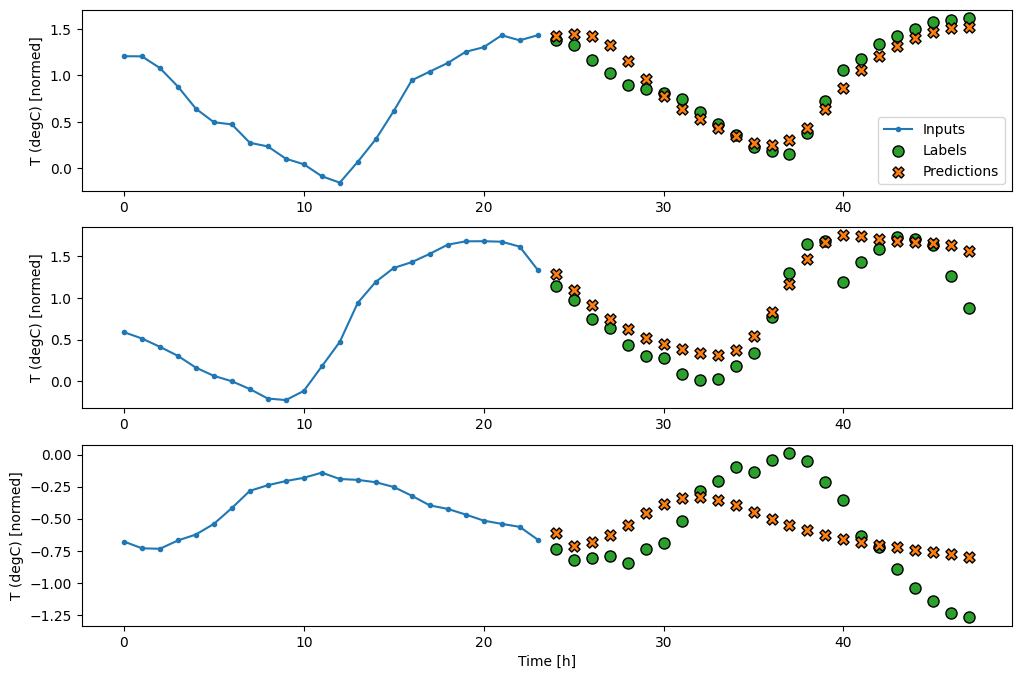

In [43]:
train_performance['RNN(multi step, feedback)'] = feedback_model.evaluate( feedback_window.train, return_dict=True)
valid_performance['RNN(multi step, feedback)'] = feedback_model.evaluate( feedback_window.valid, return_dict=True)
test_performance['RNN(multi step, feedback)'] = feedback_model.evaluate( feedback_window.test, return_dict=True, verbose=0)

# Here we plot only the temperature column.
feedback_window.plot(feedback_model, plot_col='T (degC)')


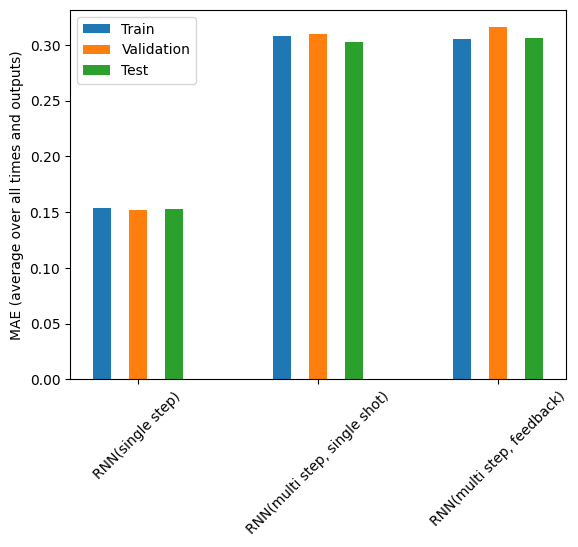

In [44]:
x = np.arange(len(train_performance))
width = 0.1

metric_name = 'mean_absolute_error'

train_mae = [v[metric_name] for v in train_performance.values()]
valid_mae = [v[metric_name] for v in valid_performance.values()]
test_mae = [v[metric_name] for v in test_performance.values()]

plt.bar(x - 0.2, train_mae, width, label='Train')
plt.bar(x,       valid_mae, width, label='Validation')
plt.bar(x + 0.2, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=train_performance.keys(),
           rotation=45)
plt.ylabel(f'MAE (average over all times and outputs)')
_ = plt.legend()

For this weather data, the accuracy of the RNN (multi step, single shot) and the RNN (multi step, feedback) is about the same for now.

However, by refining the feature engineering, the model architecture, the model's loss function, optimization algorithm, number of epochs, and so on, the results may differ.
